# **Product Review Sentiment Analysis using Machine Learning**

**Problem Statement***

Customer reviews are important for understanding whether customers are satisfied or not. Manually reading thousands of reviews is difficult, so we need a machine learning model to automatically classify reviews as **positive** or **negative.**

**Objective**

- Build a machine learning model to predict customer sentiment.
- Classify reviews as **positive** or **negative.**
- Compare different machine learning models.
- Select the model with the best prediction accuracy.

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

import warnings
warnings.filterwarnings('ignore')

**Load the Data**

In [ ]:
df = pd.read_csv("/content/Text_dataset.csv")
df.shape

(15000, 6)

In [ ]:
# Displaying the basic information of the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_name   15000 non-null  object
 1   product_price  15000 non-null  object
 2   Rate           15000 non-null  object
 3   Review         13236 non-null  object
 4   Summary        15000 non-null  object
 5   Sentiment      15000 non-null  object
dtypes: object(6)
memory usage: 703.3+ KB


In [ ]:
# Displaying the first few rows of the Dataset
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,"Google Nest Hub (2nd gen), Display with Google...",6999,1,unsatisfactory,if you like to have a digital photo frame whic...,negative
1,Seagate One Touch with Password Protection for...,5599,5,terrific purchase,nice one,positive
2,Furnifry Wooden TV Entertainment UnitWall Set ...,2969,2,slightly disappointed,quality is ok but width of side shelves is 20 ...,positive
3,Men 9325 Latest Collection Stylish Sports Snea...,299,5,NaN,very good product,positive
4,Exclusive Affordable Collection of Trendy & St...,299,1,NaN,purely worst shoe soles height is only 14th of...,negative


In [ ]:
# Checking Duplicate Records
df.duplicated().sum()

np.int64(503)

In [ ]:
# Drop Duplicates
df = df.drop_duplicates()

In [ ]:
# Checking Null\Missing Values
df.isnull().sum()

,0
product_name,0
product_price,0
Rate,0
Review,1591
Summary,0
Sentiment,0


In [ ]:
# Displaying the percentage of Null values
((df.isnull().sum())/len(df))*100

,0
product_name,0.000000
product_price,0.000000
Rate,0.000000
Review,10.974684
Summary,0.000000
Sentiment,0.000000


In [ ]:
# Handling Null Values
df["Review"] = df["Review"].fillna(df["Review"].mode()[0])

**Observations**
- The Dataset contains a total of **1500** rows and 6 features.
- All are Categorical columns (Before Preprocessing).
- The **Review** column contains about ***10%** missing values. Since it is a categorical column, the missing values were filled using the **Mode (most frequent value)** with Simple Imputer.
- The Dataset contains **503** Duplicate records.These Duplicate Records were removed using **Drop_duploicate()** method.Removing duplicate records helps improve data quality and prevents biased model predictions.


**Target Variable : Sentiment**
- The **Sentiment** column is the target variable and contains **Positive** and **Negative** classes.Hence This is a **Supervised Classification Model.**
       

**Target Variable Analysis**

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
positive,11665
negative,2058
neutral,774


**Observations :**
- The target variable **(Sentiment)** contains three classes :  Positive, Negative, and Neutral, making this a **multiclass classification problem**

- Positive reviews are the most common **(11,663)**, while Negative **(2,058)** and Neutral **(774)** reviews are fewer, indicating that the dataset is imbalanced.

# **Text Analysis and Feature Engineering**

In [ ]:
df['Text'] = df['Summary'] + ' ' + df['Review']

**Observation :**
- I combined **Review + Summary** because both are text columns and together they give more information.
- **Reason:** Both columns contain customer feedback, so combining them improves context and helps the model predict sentiment more accurately.

In [ ]:
# Counts the total number of characters in the text (including spaces and punctuation).
df['Char_count'] = df['Text'].apply(len)

# Word Count
df['word_count'] = df["Text"].str.split().apply(len)

# Sentence Count
df['sentence_count'] = df['Text'].apply(lambda x:len(str(x).split('.')))

# Average Word Length
df['avg_word_length'] = df['Text'].apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split())
    if len(str(x).split()) > 0 else 0
)

# Vocabulary Size
df['vocabulary_size'] = df['Text'].apply(
    lambda x: len(set(str(x).split()))
)


In [ ]:
import string
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Stop Word count
df["stopword_count"] = df["Text"].apply(
    lambda x: sum(1 for word in str(x).lower().split() if word in stop_words)
)

# Punctuation Count
df["punctuation_count"] = df["Text"].apply(
    lambda x: sum(1 for ch in str(x) if ch in string.punctuation)
)


In [ ]:
df.head(2)

,product_name,product_price,Rate,Review,Summary,Sentiment,Text,Char_count,word_count,sentence_count,avg_word_length,vocabulary_size,stopword_count,punctuation_count
0,"Google Nest Hub (2nd gen), Display with Google...",6999,1,unsatisfactory,if you like to have a digital photo frame whic...,negative,if you like to have a digital photo frame whic...,494,89,1,4.561798,64,44,0
1,Seagate One Touch with Password Protection for...,5599,5,terrific purchase,nice one,positive,nice one terrific purchase,26,4,1,5.750000,4,0,0


**Observations :**
- The engineered text features (character count, word count, vocabulary size, stopword count, etc.) provide additional numerical information that can help improve the performance of machine learning models.

# **Visual Analysis :**

**Uni Variate Analysis**

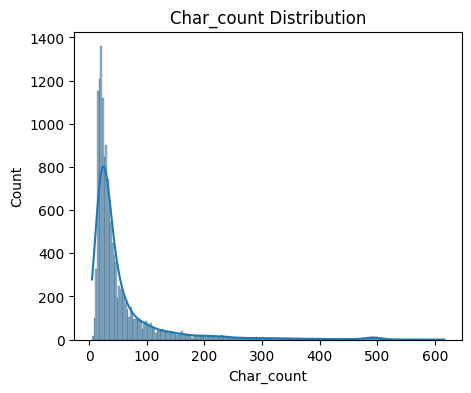

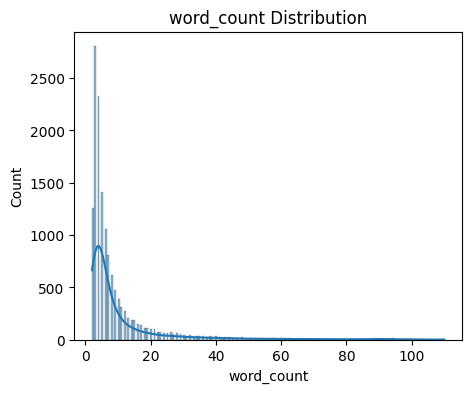

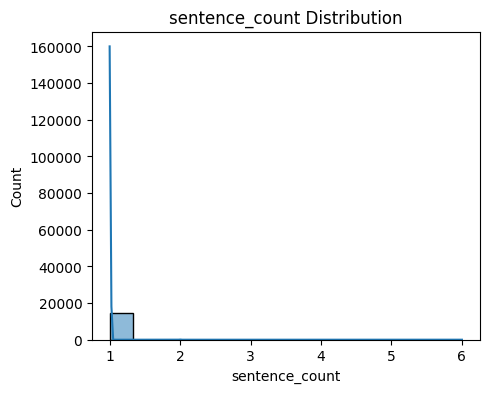

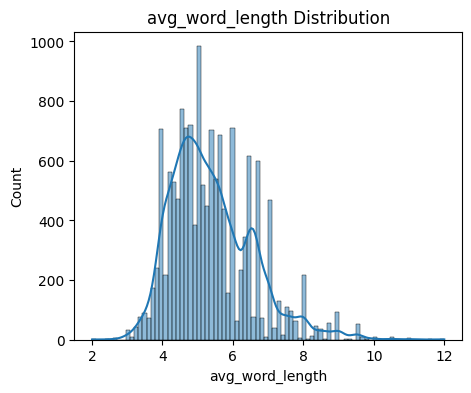

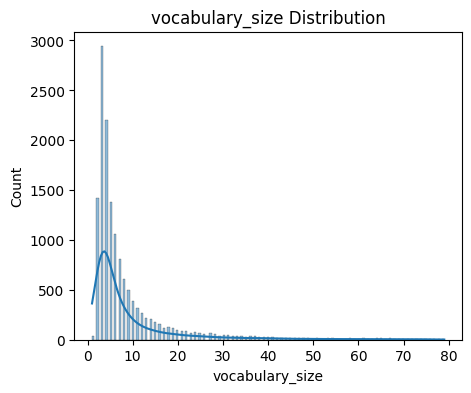

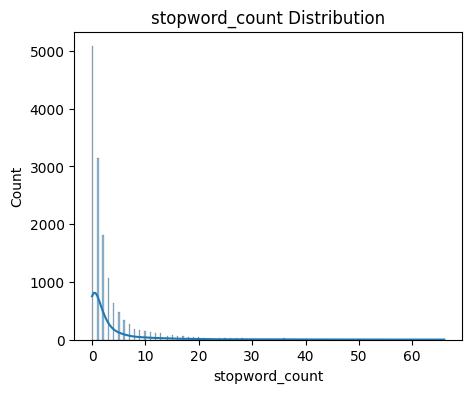

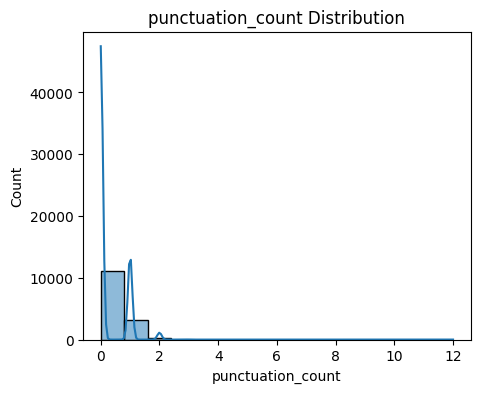

In [ ]:
# Using Histogram for Numerical Columns
num_col = df.select_dtypes(include='number')

for col in num_col:
  plt.figure(figsize=(5,4))
  sns.histplot(data=df,x=col,kde=True)
  plt.title(f"{col} Distribution")
  plt.show()

**Observations :**
- Most reviews contain a relatively small number of words.
- Extremely long reviews are rare.
- Text-related numerical features show **Right-skewed distributions**, which is common in customer review datasets.

**Word Cloud**

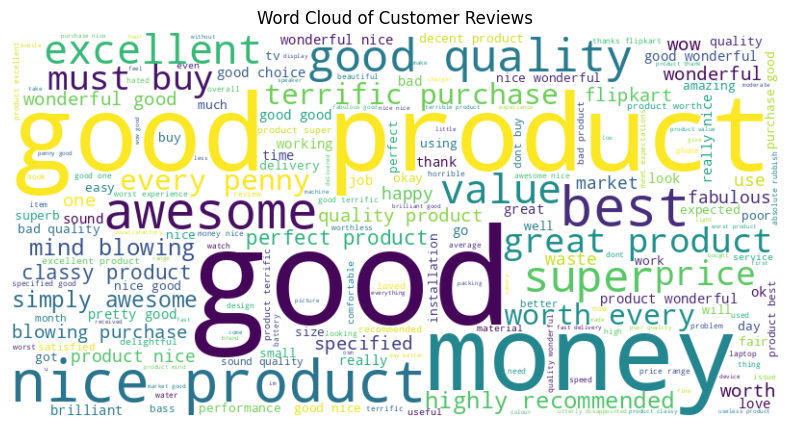

In [ ]:
from wordcloud import WordCloud

# Combine all text into one string
all_words = " ".join(df["Text"].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white'
).generate(all_words)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.show()


**Observations :**
- Frequently occurring words dominate the reviews, indicating common customer opinions.
- Positive terms appear much more often, which matches the class distribution.
- The Word Cloud provides a quick overview of the most discussed topics in customer feedback.

**Bi Variate Analysis**

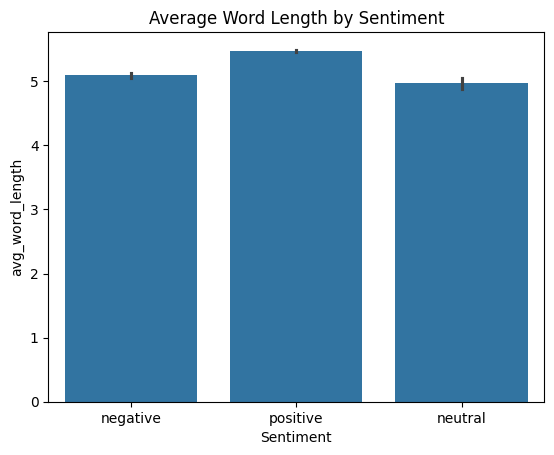

In [ ]:
# Average Text Length by Class
# Using BarPlot
sns.barplot(data=df,x="Sentiment",y="avg_word_length")
plt.title("Average Word Length by Sentiment")
plt.show()

**Observations :**
- The average word length ranges between **5.0** and **5.5** across all sentiment classes.
- Although positive reviews use slightly longer words on average, the variation is minimal.
- Therefore, the model relies more on the actual words (captured using TF-IDF) than on word length.

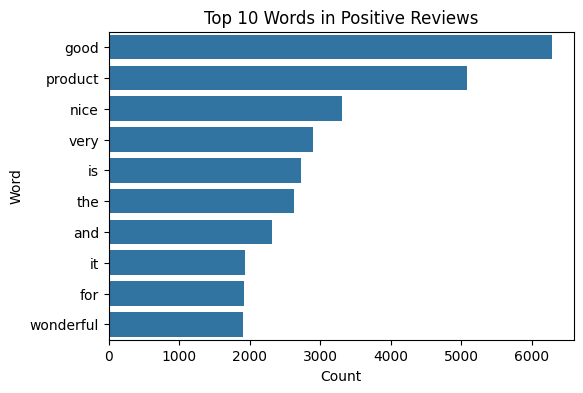

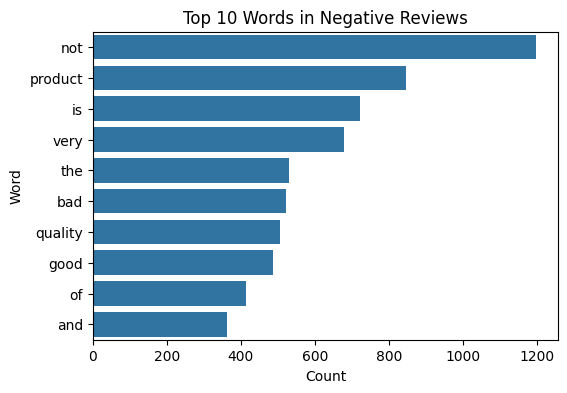

In [ ]:
# Top 10 Words Analysis
from collections import Counter

# Positive Reviews
positive_text = " ".join(df[df["Sentiment"]=="positive"]["Text"])

positive_words = Counter(positive_text.split()).most_common(10)

positive_df = pd.DataFrame(positive_words, columns=["Word","Count"])

plt.figure(figsize=(6,4))
sns.barplot(data=positive_df, x="Count", y="Word")
plt.title("Top 10 Words in Positive Reviews")
plt.show()


# Negative Reviews
negative_text = " ".join(df[df["Sentiment"]=="negative"]["Text"])

negative_words = Counter(negative_text.split()).most_common(10)

negative_df = pd.DataFrame(negative_words, columns=["Word","Count"])

plt.figure(figsize=(6,4))
sns.barplot(data=negative_df, x="Count", y="Word")
plt.title("Top 10 Words in Negative Reviews")
plt.show()

**Correlation HeatMap**

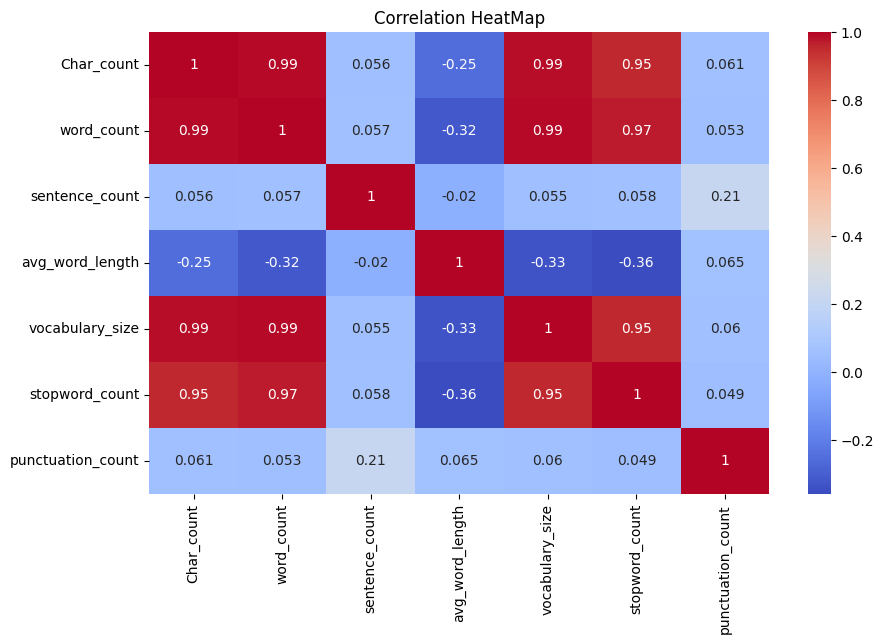

In [ ]:
# Correlation HeatMap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation HeatMap")
plt.show()

**Observations :**
- Character count, word count, and vocabulary size have a **Strong positive** relationship.
- This means that longer reviews usually contain more words and more unique words.
- Average word length has a **Weak relationship** with the other text features.
- This suggests that word length alone is not a strong factor for predicting customer sentiment.

In [ ]:
# Download required nltk data
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
def clean(doc):
    regex = "[^a-zA-Z.]"
    doc = re.sub(regex, " ", str(doc))

    # Convert to lower case
    doc = doc.lower()

    # Tokenization
    tokens = nltk.word_tokenize(doc)

    # Stopwords removal
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # Join and return
    return " ".join(lemmatized_tokens)

In [ ]:
df["clean_product_name"] = df["product_name"].apply(lambda x:clean(x))

In [ ]:
df["clean_text"] = df["Text"].apply(lambda x:clean(x))

In [ ]:
df.head(1)

,product_name,product_price,Rate,Review,Summary,Sentiment,Text,Char_count,word_count,sentence_count,avg_word_length,vocabulary_size,stopword_count,punctuation_count,clean_product_name,clean_text
0,"Google Nest Hub (2nd gen), Display with Google...",6999,1,unsatisfactory,if you like to have a digital photo frame whic...,negative,if you like to have a digital photo frame whic...,494,89,1,4.561798,64,44,0,google nest hub nd gen display google assistan...,like digital photo frame show photo google pho...


In [ ]:
df = df.drop(columns=["product_name","Text","Review","Summary"])

In [ ]:
for i, value in enumerate(df['product_price']):
    try:
        int(value)
    except:
        print(i, value)
        break

4683 Nova Plus Amaze NI 10 1100 W Dry IronGrey  Turquoise


In [ ]:
df.loc[4683]

,4683
product_price,544
Rate,5
Sentiment,positive
Char_count,26
word_count,3
sentence_count,1
avg_word_length,8.0
vocabulary_size,3
stopword_count,0
punctuation_count,1


In [ ]:
# Convert wrong values to NaN
df['product_price'] = pd.to_numeric(df['product_price'],errors='coerce')

In [ ]:
# Remove rows where price is missing/wrong
df = df.dropna(subset=['product_price'])

In [ ]:
# Convert price to integer
df['product_price'] = df['product_price'].astype(int)

In [ ]:
df['Rate'] = df['Rate'].astype(int)

**X and y**

In [ ]:
# Target column selection
y = df['Sentiment']

# Input variables (X)
X = df.drop(columns = "Sentiment")

# Print the shapes of the X and y
print(X.shape)
print(y.shape)


(14495, 11)
(14495,)


**train_test_split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(11596, 11)
(2899, 11)
(11596,)
(2899,)


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14495 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_price       14495 non-null  int64  
 1   Rate                14495 non-null  int64  
 2   Char_count          14495 non-null  int64  
 3   word_count          14495 non-null  int64  
 4   sentence_count      14495 non-null  int64  
 5   avg_word_length     14495 non-null  float64
 6   vocabulary_size     14495 non-null  int64  
 7   stopword_count      14495 non-null  int64  
 8   punctuation_count   14495 non-null  int64  
 9   clean_product_name  14495 non-null  object 
 10  clean_text          14495 non-null  object 
dtypes: float64(1), int64(8), object(2)
memory usage: 1.3+ MB


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

transformer = ColumnTransformer(transformers=[
    ('t1',TfidfVectorizer(stop_words='english'), 'clean_text'),
    ('t2',MinMaxScaler(),[0,1,2,3,4,5,6,7,8]),
    ('t3',OneHotEncoder(handle_unknown='ignore'), ['clean_product_name'])
])

**Baseline Models**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

models = {'KNN': KNeighborsClassifier(),
          'Naive Bayses': MultinomialNB(),
          'Decision Tree': DecisionTreeClassifier(),
          'Logistic Regressor': LogisticRegression()}

for name,model in models.items():
  pipe = make_pipeline(transformer,model)
  pipe.fit(X_train,y_train)
  y_pred = pipe.predict(X_test)

  print(name)
  print("Accuracy Score :" ,accuracy_score(y_test,y_pred))

KNN
Accuracy Score : 0.8906519489479131
Naive Bayses
Accuracy Score : 0.8785788202828562
Decision Tree
Accuracy Score : 0.9065194894791307
Logistic Regressor
Accuracy Score : 0.9248016557433598


**Observations :**

- **Logistic Regression** was selected as the final model due to its superior performance.

**Hyper Parameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Create a pipeline
log_pipe = make_pipeline(
    transformer,LogisticRegression(max_iter=1000,random_state=42)
)

# Hyper Parameters
param_grid = {
    'logisticregression__C': [0.001,0.01,0.1, 1, 10, 100],
    'logisticregression__solver': ['liblinear','lbfgs'],
    'logisticregression__penalty': ['l2']
}

# RandomSearchCV
random = RandomizedSearchCV(
    estimator = log_pipe,
    param_distributions = param_grid,
    n_iter=20,
    cv = 5,
    random_state = 42,
    n_jobs=-1,
    verbose = 1
)

# Train
random.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('columntransformer',
                                              ColumnTransformer(transformers=[('t1',
                                                                               TfidfVectorizer(stop_words='english'),
                                                                               'clean_text'),
                                                                              ('t2',
                                                                               MinMaxScaler(),
                                                                               [0,
                                                                                1,
                                                                                2,
                                                                                3,
                                                                                4,
                                                                                5,
                                                                                6,
                                                                                7,
                                                                                8]),
                                                                              ('t3',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['clean_product_name'])])),
                                             ('logisticregression',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'logisticregression__C': [0.001, 0.01,
                                                                  0.1, 1, 10,
                                                                  100],
                                        'logisticregression__penalty': ['l2'],
                                        'logisticregression__solver': ['liblinear',
                                                                       'lbfgs']},
                   random_state=42, verbose=1)

In [ ]:
# Best Parameters and Best CV score
print("Best Parameters :", random.best_params_)
print("Best Cross Validation Score :", random.best_score_)


Best Parameters : {'logisticregression__solver': 'lbfgs', 'logisticregression__penalty': 'l2', 'logisticregression__C': 1}
Best Cross Validation Score : 0.9285099478074675


**Model Evaluation**

In [ ]:
# Test Accuracy
y_predicted = random.predict(X_test)
print("Test Accuracy :",accuracy_score(y_test,y_predicted))

Test Accuracy : 0.9248016557433598


**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

    negative       0.86      0.84      0.85       429
     neutral       0.73      0.37      0.49       165
    positive       0.94      0.98      0.96      2305

    accuracy                           0.92      2899
   macro avg       0.84      0.73      0.77      2899
weighted avg       0.92      0.92      0.92      2899



**Observations :**
- The Logistic Regression model achieved an overall accuracy of **92.48%**, with the best performance on the Positive class, while the Neutral class showed comparatively lower performance.

**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_predicted))

[[ 362   10   57]
 [  26   61   78]
 [  34   13 2258]]


**Observations :**
- Most reviews were correctly classified into their actual sentiment classes, with only a small number of misclassifications, indicating good overall model performance.

**Save Complete Pipeline**

In [ ]:
import joblib

joblib.dump(random.best_estimator_, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

# **Conclusion**

- Successfully developed a multiclass sentiment analysis model using **customer reviews.**

- Applied comprehensive text preprocessing, feature engineering, TF-IDF vectorization, and machine learning techniques.
- Compared multiple classification algorithms and selected Logistic Regression as the best-performing model.
- Achieved **92.48%** test accuracy, demonstrating **Strong predictive performance.**
- The trained pipeline was saved using **Joblib** and is ready for deployment in a **Streamlit** application.